In [1]:
import numpy as np
from matplotlib import pyplot as plt

import sklearn
import urllib.request

import pandas as pd

In [2]:
data = pd.read_csv("../solutions/galaxyquasar.csv")
data

,u,g,r,i,z,class,z1,zerr
0,18.97213,18.53676,18.58280,18.34936,18.29215,QSO,0.522819,0.000155
1,19.24592,17.47646,16.47817,16.04472,15.68851,GALAXY,0.122846,0.000028
2,19.43536,17.70268,16.91565,16.58327,16.39128,GALAXY,0.000000,0.000000
3,19.31626,18.18312,17.39591,16.94549,16.65395,GALAXY,0.147435,0.000009
4,19.28828,19.11188,18.88937,18.80013,18.49183,QSO,2.011455,0.000631
...,...,...,...,...,...,...,...,...
49995,19.37295,18.12382,17.39886,16.98503,16.70585,GALAXY,0.113016,0.000011
49996,18.52021,16.88262,16.03280,15.56884,15.22454,GALAXY,0.085063,0.000014
49997,18.62718,17.30876,16.87371,16.62399,16.42296,GALAXY,0.054429,0.000008
49998,19.55140,18.27711,17.62101,17.21947,17.03347,GALAXY,0.112571,0.000009


In [3]:
u_g = np.array(data['u']-data['g'])
g_r = np.array(data['g']-data['r'])
r_i = np.array(data['r']-data['i'])
i_z = np.array(data['i']-data['z'])
z = np.array(data['z1'])
zerr = np.array(data['zerr'])

In [4]:
cls = []
for c in data['class']:
    if c=='QSO': cls = np.append(cls, 1)
    elif c=='GALAXY': cls = np.append(cls, 0)

Text(0, 0.5, 'i - z')

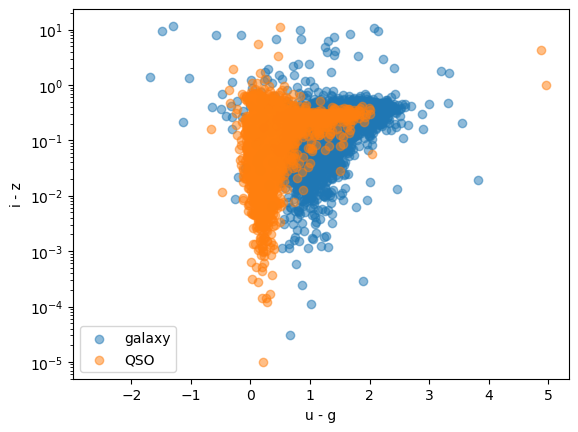

In [5]:
plt.scatter(u_g[cls==0],i_z[cls==0], label='galaxy',alpha=0.5)
plt.scatter(u_g[cls==1],i_z[cls==1], label='QSO',alpha=0.5)
plt.legend()
plt.yscale('log')
plt.xlabel('u - g')
plt.ylabel('i - z')
#plt.xscale('log')

In [6]:
from sklearn.naive_bayes import GaussianNB

X = np.array([u_g, g_r, r_i, i_z, z]).T
y = cls

gnb = GaussianNB()
gnb.fit(X,y)

y_pred = gnb.predict(X)
X.shape

(50000, 5)

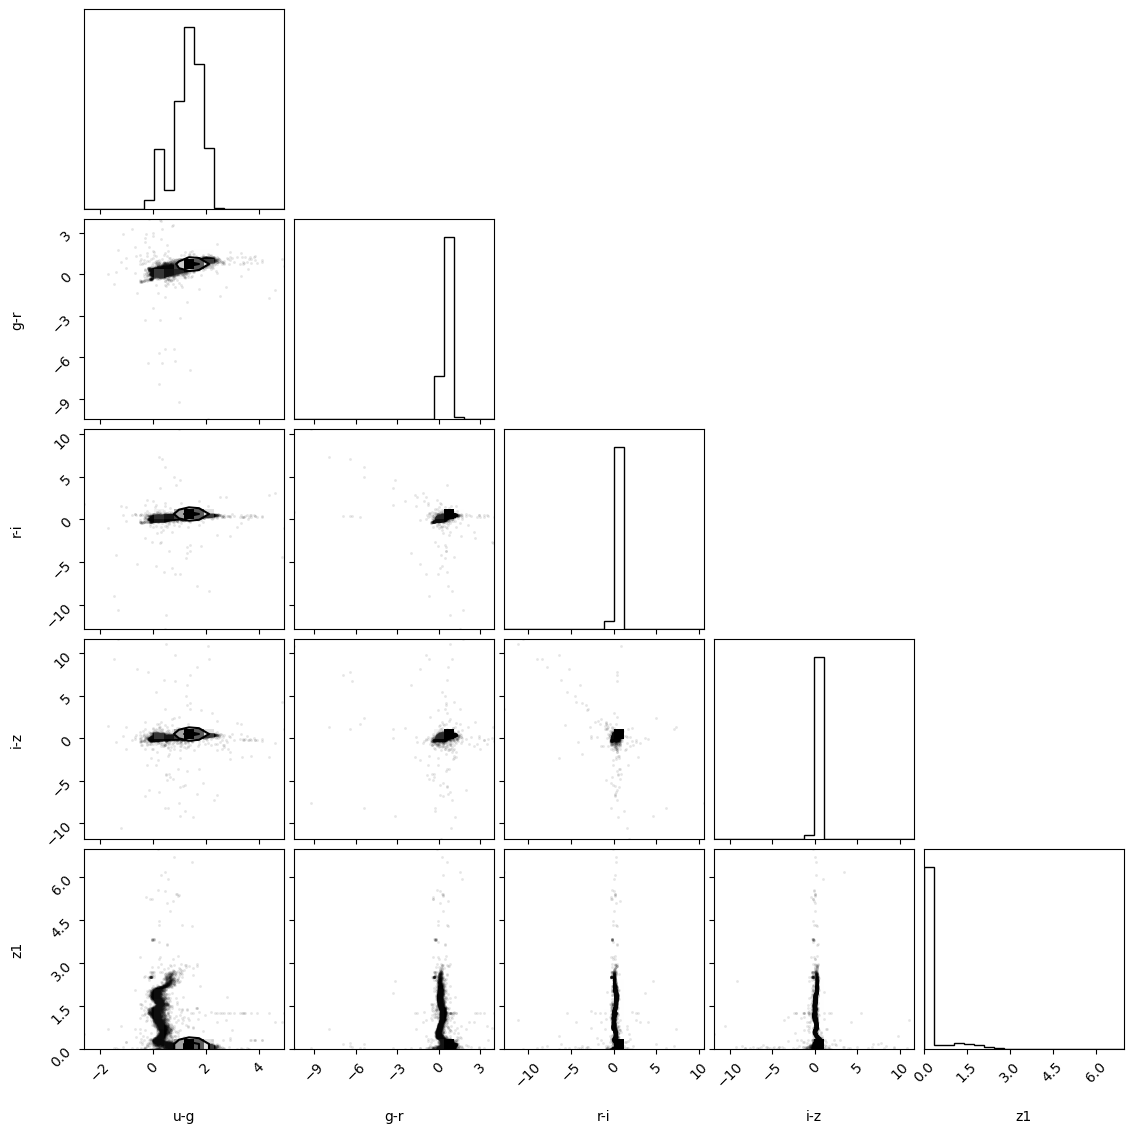

In [7]:
import corner
corner.corner(np.array([u_g,g_r,r_i,i_z,z]).T, labels=['u-g', 'g-r', 'r-i', 'i-z','z1']);

In [8]:
from sklearn.naive_bayes import GaussianNB
from astroML.utils import split_samples
from astroML.utils import completeness_contamination
from sklearn.metrics import precision_recall_curve, roc_curve


(X_train, X_test), (y_train, y_test) = split_samples(X, y, [0.75, 0.25],
                                                     random_state=0)

GAUSSIAN NAIVE BAYES
-

In [9]:
gnb = GaussianNB()
gnb.fit(X_train,y_train)

y_pred_gnb = gnb.predict(X_test)

In [10]:
y_pred_gnb[y_pred_gnb==0].shape, y_test[y_test==0].shape
y_pred_gnb[y_pred_gnb==1].shape, y_test[y_test==1].shape

((1740,), (1764,))

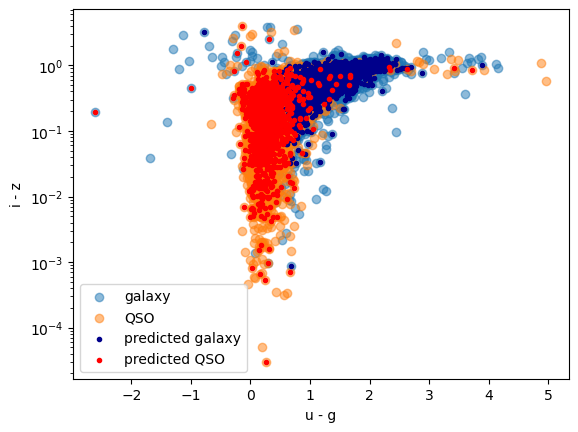

In [11]:
plt.scatter(u_g[cls==0],g_r[cls==0], label='galaxy',alpha=0.5)
plt.scatter(u_g[cls==1],g_r[cls==1], label='QSO',alpha=0.5)

plt.scatter(X_test[:,0][y_pred_gnb==0],X_test[:,1][y_pred_gnb==0],label='predicted galaxy',marker='.',c='darkblue',edgecolors=None)
plt.scatter(X_test[:,0][y_pred_gnb==1],X_test[:,1][y_pred_gnb==1],label='predicted QSO',marker='.',c='r')

plt.xlabel('u - g')
plt.ylabel('i - z')

plt.legend()
plt.yscale('log')

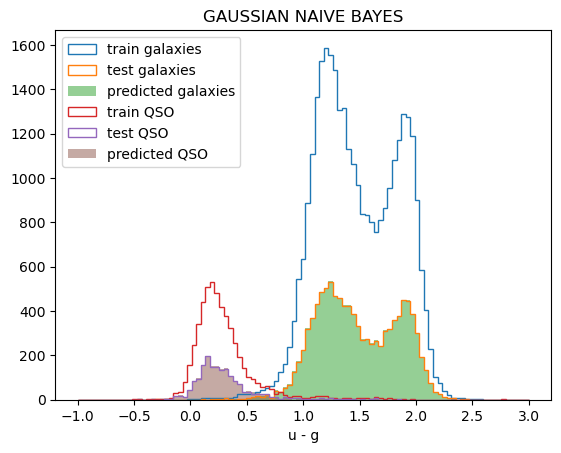

In [12]:
bins = np.linspace(-1,3,100)

plt.hist(X_train[:,0][y_train==0], bins, histtype='step', label='train galaxies', density=False)
plt.hist(X_test[:,0][y_test==0], bins, histtype='step', label='test galaxies', density=False)
plt.hist(X_test[:,0][y_pred_gnb==0], bins,  label='predicted galaxies', density=False, alpha = 0.5)



plt.hist(X_train[:,0][y_train==1], bins, histtype='step', label='train QSO', density=False)
plt.hist(X_test[:,0][y_test==1], bins, histtype='step', label='test QSO', density=False)
plt.hist(X_test[:,0][y_pred_gnb==1], bins,  label='predicted QSO', density=False, alpha = 0.5)



plt.title('GAUSSIAN NAIVE BAYES')
# each hist is normalized singularly, don't mind the different heights between gal and qso
plt.xlabel('u - g')
plt.legend();

In [13]:
completeness, contamination = completeness_contamination(y_pred_gnb, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.9285714285714286
contamination 0.05862068965517241


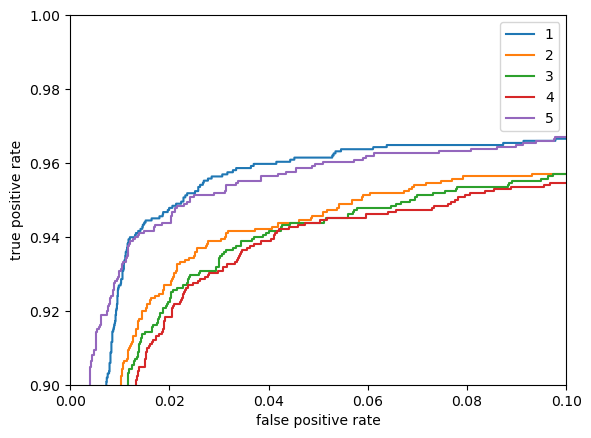

In [14]:
classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)

y_prob = np.array([])

for nc in Ncolors:
    clf = GaussianNB()
    clf.fit(X_train[:, :nc], y_train)
    y_pred = clf.predict(X_test[:, :nc])
    # Gives the probability for both classes, take just one
    y_prob = np.append(y_prob,clf.predict_proba(X_test[:, :nc])[:,1])

    classifiers.append(clf)
    predictions.append(y_pred)
    
    y_prob = clf.predict_proba(X_test[:,:nc]) [:,1] 
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(nc))
    
plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)

plt.xlabel('false positive rate')
plt.ylabel('true positive rate');

In [15]:
completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness [0.92743764 0.92403628 0.91666667 0.91609977 0.92857143]
contamination [0.06300115 0.1029169  0.10465116 0.11159978 0.05862069]


LINEAR & QUADRATIC DISCRIMINANT ANALYSIS
-

In [16]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis as LDA
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis as QDA


lda = LDA()
lda.fit(X_train,y_train)
y_pred_lda = lda.predict(X_test)

qda = QDA()
qda.fit(X_train,y_train)
y_pred_qda = qda.predict(X_test)

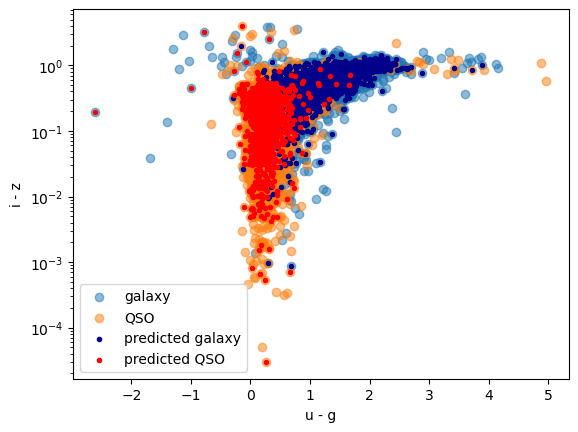

In [17]:
plt.scatter(u_g[cls==0],g_r[cls==0], label='galaxy',alpha=0.5)
plt.scatter(u_g[cls==1],g_r[cls==1], label='QSO',alpha=0.5)

#plt.scatter(X_train[:,0][y_train==0],X_train[:,-2][y_train==0],label='training galaxy',alpha=0.5)
#plt.scatter(X_test[:,0][y_pred_lda==1],X_test[:,-2][y_pred_lda==1],label='training QSO',alpha=0.5)

plt.scatter(X_test[:,0][y_pred_lda==0],X_test[:,1][y_pred_lda==0],label='predicted galaxy',marker='.',c='darkblue')
plt.scatter(X_test[:,0][y_pred_lda==1],X_test[:,1][y_pred_lda==1],label='predicted QSO',marker='.',c='r')

plt.legend()
plt.yscale('log')

plt.xlabel('u - g')
plt.ylabel('i - z');

In [18]:
completeness, contamination = completeness_contamination(y_pred_lda, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.8208616780045351
contamination 0.0061770761839396015


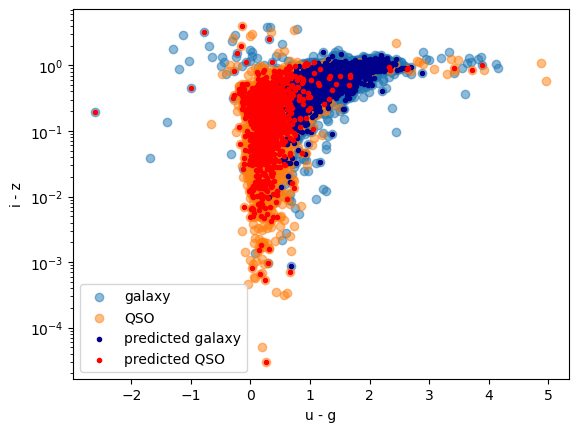

In [19]:
plt.scatter(u_g[cls==0],g_r[cls==0], label='galaxy',alpha=0.5)
plt.scatter(u_g[cls==1],g_r[cls==1], label='QSO',alpha=0.5)

plt.scatter(X_test[:,0][y_pred_qda==0],X_test[:,1][y_pred_qda==0],label='predicted galaxy',marker='.',c='darkblue',edgecolors=None)
plt.scatter(X_test[:,0][y_pred_qda==1],X_test[:,1][y_pred_qda==1],label='predicted QSO',marker='.',c='r')


plt.legend()
plt.yscale('log')

plt.xlabel('u - g')
plt.ylabel('i - z');

In [20]:
completeness, contamination = completeness_contamination(y_pred_qda, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.941609977324263
contamination 0.04595060310166571


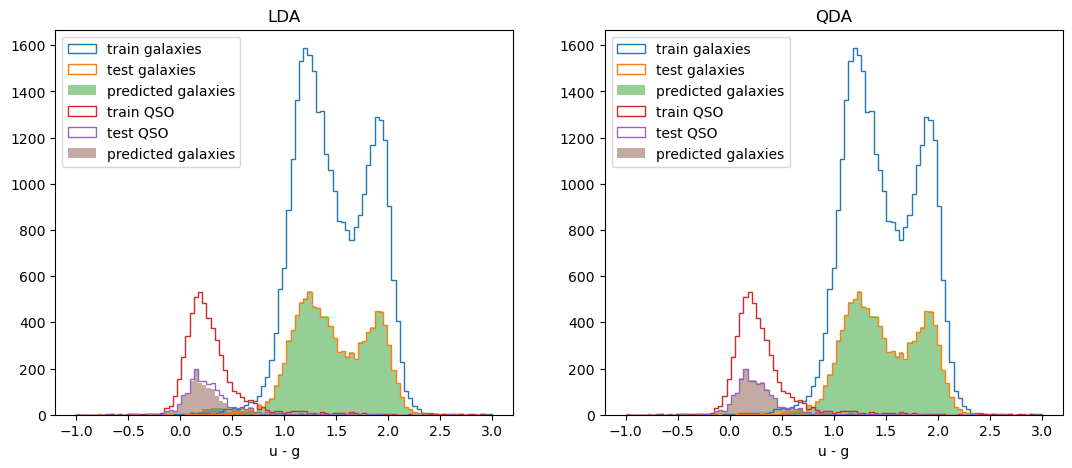

In [21]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
ax, ax1 = axes

ax.hist(X_train[:,0][y_train==0], bins, histtype='step', label='train galaxies' )
ax.hist(X_test[:,0][y_test==0], bins, histtype='step', label='test galaxies' )
ax.hist(X_test[:,0][y_pred_lda==0], bins,  label='predicted galaxies' , alpha = 0.5)


ax.hist(X_train[:,0][y_train==1], bins, histtype='step', label='train QSO' )
ax.hist(X_test[:,0][y_test==1], bins, histtype='step', label='test QSO' )
ax.hist(X_test[:,0][y_pred_lda==1], bins,  label='predicted galaxies' , alpha = 0.5)


ax.set_title('LDA')
ax.set_xlabel('u - g')
ax.legend()

ax1.hist(X_train[:,0][y_train==0], bins, histtype='step', label='train galaxies' )
ax1.hist(X_test[:,0][y_test==0], bins, histtype='step', label='test galaxies' )
ax1.hist(X_test[:,0][y_pred_qda==0], bins, label='predicted galaxies' , alpha = 0.5)


ax1.hist(X_train[:,0][y_train==1], bins, histtype='step', label='train QSO' )
ax1.hist(X_test[:,0][y_test==1], bins, histtype='step', label='test QSO' )
ax1.hist(X_test[:,0][y_pred_qda==1], bins,  label='predicted galaxies' , alpha = 0.5)


ax1.set_title('QDA')
ax1.set_xlabel('u - g')
ax1.legend();

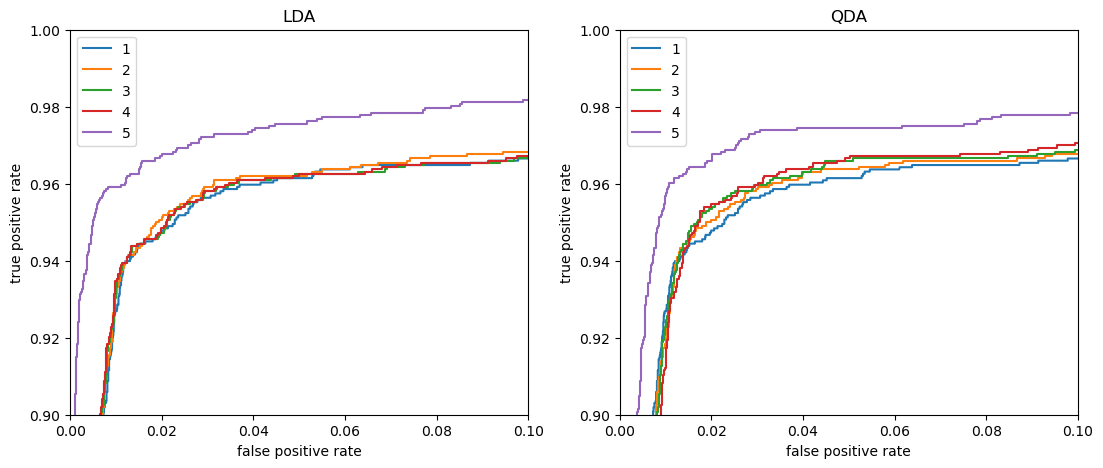

In [22]:
fig, axes = plt.subplots(1,2, figsize=(13,5))
ax, ax1 = axes


for nc in Ncolors:

    lda.fit(X_train[:,0:nc] ,y_train )
    
    y_prob = lda.predict_proba(X_test[:,0:nc]) [:,1] 
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    ax.plot(fpr, tpr, label=str(nc))

ax.set_title('LDA')
ax.legend()
ax.set_xlim(0,0.1)
ax.set_ylim(0.9,1)

for nc in Ncolors:

    qda.fit(X_train[:,0:nc] ,y_train )
    
    y_prob = qda.predict_proba(X_test[:,0:nc]) [:,1] 
    
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    ax1.plot(fpr, tpr, label=str(nc))
    
ax1.set_title('QDA')  
ax1.legend()
ax1.set_xlim(0,0.1)
ax1.set_ylim(0.9,1)

ax.set_xlabel('false positive rate')
ax.set_ylabel('true positive rate')
ax1.set_xlabel('false positive rate')
ax1.set_ylabel('true positive rate');

In [23]:
completenessLDA, contaminationLDA = completeness_contamination(y_pred_lda, y_test)
completenessQDA, contaminationQDA = completeness_contamination(y_pred_qda, y_test)

print("completeness LDA: ", completenessLDA,"\ncompleteness QDA: ", completenessQDA)
print("contamination LDA: ", contaminationLDA,"\ncontamination QDA: ", contaminationQDA)

completeness LDA:  0.8208616780045351 
completeness QDA:  0.941609977324263
contamination LDA:  0.0061770761839396015 
contamination QDA:  0.04595060310166571


GMM AND BAYES CLASSIFICATION
-


In [24]:
from astroML.classification import GMMBayes

gmmb = GMMBayes(3) # 3 clusters per class
gmmb.fit(X_train,y_train)

y_pred_gmmb = gmmb.predict(X_test)

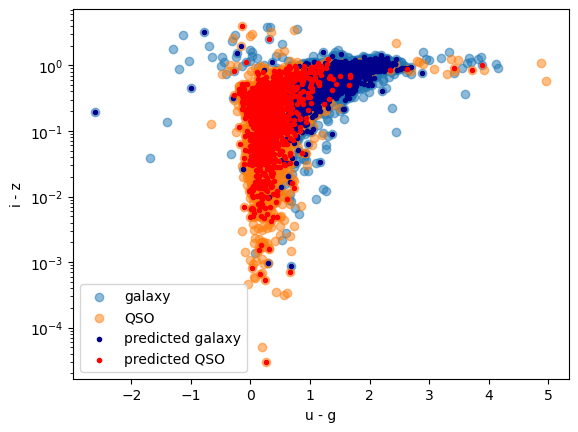

In [25]:
plt.scatter(u_g[cls==0],g_r[cls==0], label='galaxy',alpha=0.5)
plt.scatter(u_g[cls==1],g_r[cls==1], label='QSO',alpha=0.5)

plt.scatter(X_test[:,0][y_pred_gmmb==0],X_test[:,1][y_pred_gmmb==0],label='predicted galaxy',marker='.',c='darkblue',edgecolors=None)
plt.scatter(X_test[:,0][y_pred_gmmb==1],X_test[:,1][y_pred_gmmb==1],label='predicted QSO',marker='.',c='r')


plt.legend()
plt.yscale('log')


plt.xlabel('u - g')
plt.ylabel('i - z');

In [26]:
completeness, contamination = completeness_contamination(y_pred_gmmb, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.9642857142857143
contamination 0.054474708171206226


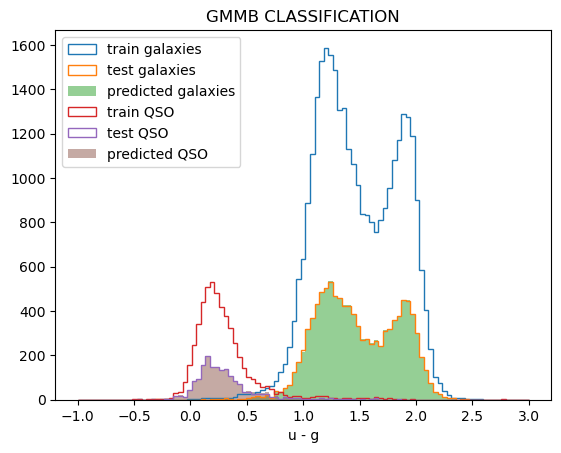

In [27]:
plt.hist(X_train[:,0][y_train==0], bins, histtype='step', label='train galaxies')
plt.hist(X_test[:,0][y_test==0], bins, histtype='step', label='test galaxies')
plt.hist(X_test[:,0][y_pred_gmmb==0], bins, label='predicted galaxies', alpha = 0.5)

plt.hist(X_train[:,0][y_train==1], bins, histtype='step', label='train QSO')
plt.hist(X_test[:,0][y_test==1], bins, histtype='step', label='test QSO')
plt.hist(X_test[:,0][y_pred_gmmb==1], bins, label='predicted QSO', alpha = 0.5)


plt.title('GMMB CLASSIFICATION')
plt.xlabel('u - g')
plt.legend();

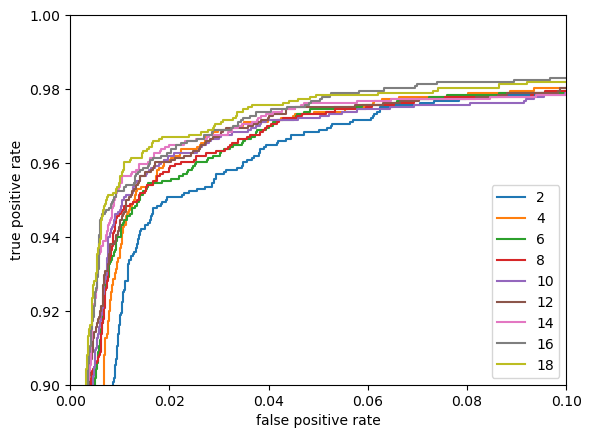

In [28]:
for n in np.arange(2,20)[::2]:
    
    clf = GMMBayes(n_components=n)
    clf.fit(X_train[:,0:4],y_train)
    
    y_prob = clf.predict_proba(X_test[:,0:4]) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(n))

plt.legend()
plt.xlim(0,0.1)
plt.ylim(0.9,1)

plt.xlabel('false positive rate')
plt.ylabel('true positive rate');

In [29]:
Ncolors = np.arange(1, X.shape[1] + 1)
Ncomp = [1, 5]


def compute_GMMbayes(Ncolors, Ncomp):
    classifiers = []
    predictions = []

    for ncm in Ncomp:
        classifiers.append([])
        predictions.append([])
        for nc in Ncolors:
            clf = GMMBayes(ncm, tol=1E-5, covariance_type='full')
            clf.fit(X_train[:, :nc], y_train)
            y_pred = clf.predict(X_test[:, :nc])

            classifiers[-1].append(clf)
            predictions[-1].append(y_pred)

    return classifiers, predictions
    
classifiers, predictions = compute_GMMbayes(Ncolors, Ncomp)
completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

/home/elisa/miniconda3/envs/fermipy/lib/python3.9/site-packages/sklearn/mixture/_base.py:269: ConvergenceWarning: Best performing initialization did not converge. Try different init parameters, or increase max_iter, tol, or check for degenerate data.
  warnings.warn(


completeness [[0.92743764 0.93027211 0.92687075 0.92573696 0.94160998]
 [0.93424036 0.91950113 0.9314059  0.9393424  0.95578231]]
contamination [[0.06300115 0.0665529  0.0651801  0.06632361 0.0459506 ]
 [0.06575964 0.05201636 0.03974284 0.06962381 0.02033701]]


K-NEAREST NEIGHBOR CLASSIFIER
-

In [30]:
from sklearn.neighbors import KNeighborsClassifier

knc = KNeighborsClassifier(5) # use 5 nearest neighbors
knc.fit(X_train,y_train)

y_pred_k = knc.predict(X_test)

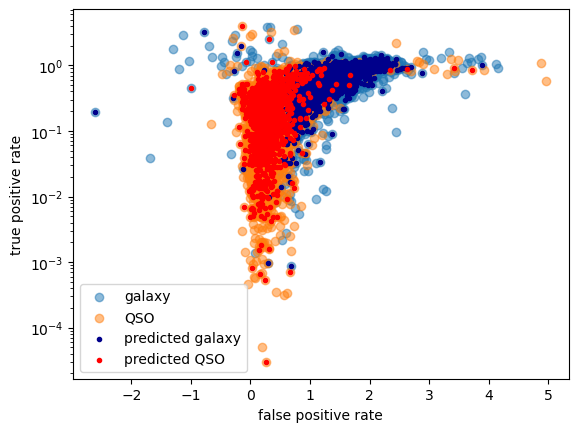

In [31]:
plt.scatter(u_g[cls==0],g_r[cls==0], label='galaxy',alpha=0.5)
plt.scatter(u_g[cls==1],g_r[cls==1], label='QSO',alpha=0.5)

plt.scatter(X_test[:,0][y_pred_k==0],X_test[:,1][y_pred_k==0],label='predicted galaxy',marker='.',c='darkblue',edgecolors=None)
plt.scatter(X_test[:,0][y_pred_k==1],X_test[:,1][y_pred_k==1],label='predicted QSO',marker='.',c='r')


plt.legend()
plt.yscale('log')

plt.xlabel('false positive rate')
plt.ylabel('true positive rate');

In [32]:
completeness, contamination = completeness_contamination(y_pred_k, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness 0.9603174603174603
contamination 0.013395457192778102


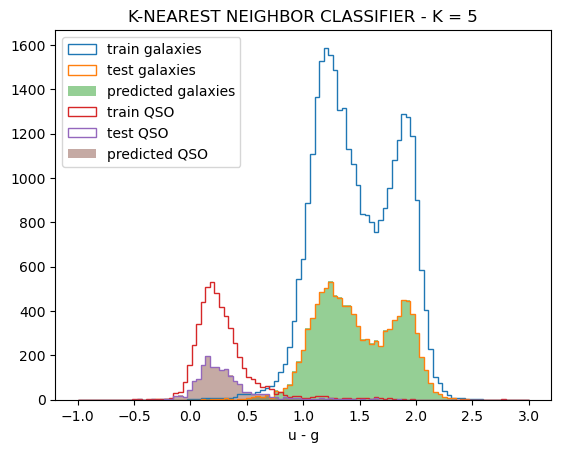

In [33]:
plt.hist(X_train[:,0][y_train==0], bins, histtype='step', label='train galaxies')
plt.hist(X_test[:,0][y_test==0], bins, histtype='step', label='test galaxies')
plt.hist(X_test[:,0][y_pred_k==0], bins, label='predicted galaxies', alpha = 0.5)

plt.hist(X_train[:,0][y_train==1], bins, histtype='step', label='train QSO')
plt.hist(X_test[:,0][y_test==1], bins, histtype='step', label='test QSO')
plt.hist(X_test[:,0][y_pred_k==1], bins, label='predicted QSO', alpha = 0.5)

plt.title('K-NEAREST NEIGHBOR CLASSIFIER - K = 5')
plt.xlabel('u - g')
plt.legend();

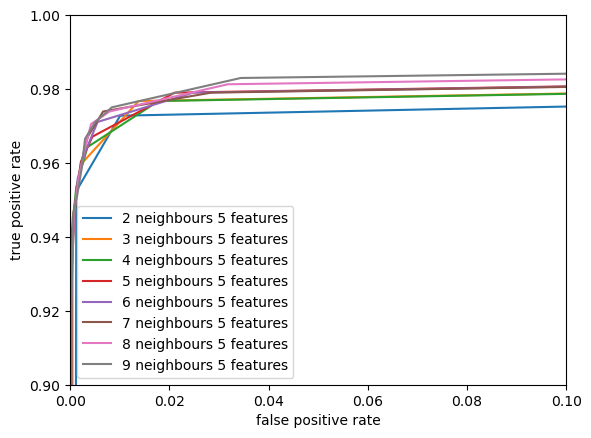

In [34]:
classifiers = []
predictions = []
Ncolors = np.arange(1, X.shape[1] + 1)
kvals = np.arange(2,10)

for k in kvals:
    classifiers.append([])
    predictions.append([])
    #for nc in Ncolors:
    nc = len(Ncolors-1)
    clf = KNeighborsClassifier(n_neighbors=k)
    clf.fit(X_train[:, :nc], y_train)
    y_pred = clf.predict(X_test[:, :nc])

    classifiers[-1].append(clf)
    predictions[-1].append(y_pred)
    y_prob = clf.predict_proba(X_test[:,:nc]) [:,1] 
        
    fpr, tpr, thresh = roc_curve(y_test, y_prob)
    plt.plot(fpr, tpr, label=str(k)+' neighbours ' + str(nc) + ' features')

plt.legend()
plt.xlabel('false positive rate')
plt.ylabel('true positive rate')
plt.xlim(0,0.1)
plt.ylim(0.9,1);



In [35]:
completeness, contamination = completeness_contamination(predictions, y_test)

print("completeness", completeness)
print("contamination", contamination)

completeness [[0.95238095]
 [0.95975057]
 [0.95351474]
 [0.96031746]
 [0.95578231]
 [0.95975057]
 [0.95578231]
 [0.95804989]]
contamination [[0.00767868]
 [0.01397787]
 [0.00766962]
 [0.01339546]
 [0.00940071]
 [0.01340326]
 [0.01056338]
 [0.01400233]]
